## Import TensorFlow and other libraries

In [1]:
import tensorflow as tf
import tensorflow_io as tfio
import tensorflow_addons as tfa
from tensorflow.keras.models import load_model

import os
from pathlib import Path
import time
import datetime
import numpy as np
import cv2
from itertools import combinations

from matplotlib import pyplot as plt
from IPython.display import display, clear_output, update_display
from tqdm.notebook import tqdm

from joblib import Memory
from joblib import Parallel, delayed
import face_recognition
import random
from scipy.interpolate import LinearNDInterpolator
from scipy import stats

import mediapipe as mp

2023-05-15 23:31:21.353415: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-05-15 23:31:21.403502: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/usr/local/lib/python3.8/dist-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow com

In [2]:
COHERENCE_LOSS = None
MAIN_LOSS = "l1"
LANDMARKS_LOSS = "displacements"
LANDMARKS_COHERENCE_LOSS = "displacements"

# Dimensions
BATCH_SIZE = 1
IMG_WIDTH = 64
IMG_HEIGHT = 64
N_CHANNELS = 3

N_LANDMARKS = 68


STEPS = 100000
# STEPS = 5000

LAMBDA1 = 1000
LAMBDA2 = 200
LAMBDA3 = 1000
LAMBDA4 = 200

VIDEOS_FOLDER = 'mug64'
BASE_PATH = Path('../')
DATA_PATH = BASE_PATH / 'data'
APP_PATH = BASE_PATH / 'app'

## Load the dataset

In [3]:
videos_path = list((DATA_PATH / VIDEOS_FOLDER).glob('**/*.npy'))

In [4]:
# Normalizing the images to [-1, 1]
def normalize(sequence):
  return (sequence / 127.5) - 1

# Undo normalizing the images to [0, 255]
@tf.function
def normalized_sequence_to_images(sequence):
  return tf.cast((sequence + 1) * 127.5, tf.uint8)

In [5]:
def plot_sample_sequence(sample_sequence):
    plot_sequence = list(sample_sequence)
    n_frames = len(plot_sequence)
    if n_frames > 20:
        plot_sequence = plot_sequence[:20]
        n_frames = 20
    rows = ((n_frames-1) // 10)+1
    cols = max(n_frames % 10, 10)
    fig = plt.figure(figsize=(20, 4))
    for i, im in enumerate(plot_sequence):
        ax = fig.add_subplot(rows,cols,i+1)
        ax.imshow(im) 
        ax.axis('off')
    plt.show()
    plt.close()

def plot_frame(frame, title=None):
    plt.imshow(frame)
    if title is not None:
        plt.title(title)
    plt.axis('off')
    plt.show()
    plt.close()

def plot_normalized_frame(frame, title=None):
    plot_frame(normalized_sequence_to_images(frame), title)

def sequence_generator(sample_sequence):
    for i in range(sample_sequence.shape[0]):
        yield sample_sequence[i, ...]

def plot_sequence(sample_sequence):
    plot_sample_sequence(sequence_generator(sample_sequence))

def plot_normalized_sequence(sample_sequence):
    plot_sequence(normalized_sequence_to_images(sample_sequence))

def inverse_sequence_generator(sample_sequence):
    for i in range(sample_sequence.shape[-1]):
        yield sample_sequence[..., i]

def plot_inverse_sequence(sample_sequence):
    plot_sample_sequence(inverse_sequence_generator(sample_sequence))

def plot_normalized_inverse_sequence(sample_sequence):
    plot_inverse_sequence(normalized_sequence_to_images(sample_sequence))

def plot_normalized_sequence(sample_sequence):
    plot_sequence(normalized_sequence_to_images(sample_sequence))

def plot_sequence_from_tensor(sample_sequence):
    if len(sample_sequence.shape) == 5 and sample_sequence.shape[0] == 1:
        plot_sequence(sample_sequence[0])
    else:
        raise ValueError("The tensor must be of shape (1, frames, height, width, channels)")

def plot_sequence_from_normalized_tensor(sample_sequence):
    plot_sequence_from_tensor(normalized_sequence_to_images(sample_sequence))

## Build an input pipeline with `tf.keras.utils.Sequence`

In [6]:
DATASET_SIZE = len(videos_path)
train_size = int(0.7 * DATASET_SIZE)
# val_size = int(0.15 * DATASET_SIZE)
test_size = int(0.3 * DATASET_SIZE)

# generate training, validation and test sets
train_paths = videos_path[:train_size]
# val_sequences = sequences[train_size:train_size+val_size]
# test_sequences = sequences[train_size+val_size:]
test_paths = videos_path[train_size:]

tf.print(len(train_paths))
tf.print(len(test_paths))

722
310


2023-05-15 23:31:27.127876: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1635] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14112 MB memory:  -> device: 0, name: NVIDIA RTX A4000, pci bus id: 0000:b3:00.0, compute capability: 8.6


In [7]:
class FrameDataGenerator():
    
    def __init__(self, videos_path, batch_size=1):
        self.videos_path = videos_path
        self.n = len(videos_path)
        self._restart()
        self.batch_size = batch_size
    
    def _load_current_video(self):
        self.current_video = np.load(self.videos_path[self.current_video_index])
    
    def __iter__(self):
        return self
    
    def _load_next_video(self):
        self.current_frame_index = 1
        self.current_video_index += 1
        self._load_current_video()
    
    def _restart(self):
        self.current_video_index = 0
        self.current_frame_index = 0
        self._load_current_video()
    

    def _current_frame(self):
        return self.current_video[self.current_frame_index]
    
    def _next_frame(self):
        return self.current_video[self.current_frame_index+1]
    
    def _previous_frame(self):
        return self.current_video[self.current_frame_index-1]
    
    def _current_video_has_next_frame(self):
        return self.current_frame_index+1 < self.current_video.shape[0]
    
    def _has_current_video(self):
        return self.current_video_index < self.n
    
    def _has_next_video(self):
        return self.current_video_index+1 < self.n
    
    def _end_of_videos(self):
            raise StopIteration
    
    def _get_current_frames(self):
        return self._previous_frame(), self._current_frame(), self._next_frame()
    
    def _get_batch(self):
        batch_previous_frame = []
        batch_current_frame = []
        batch_next_frame = []
        for i in range(self.batch_size):
            previous_frame, current_frame, next_frame = self._get_current_frames()
            batch_previous_frame.append(previous_frame)
            batch_current_frame.append(current_frame)
            batch_next_frame.append(next_frame)
        return np.array(batch_previous_frame), np.array(batch_current_frame), np.array(batch_next_frame)


    def __next__(self): # TODO: fix to consider batch size
        self.current_frame_index += 1 # Frame index start at one because we have to return the previous frame
        if not self._has_current_video():
            self._end_of_videos()
        while not self._current_video_has_next_frame():
            if self._has_next_video():
                self._load_next_video()
            else:
                self._end_of_videos()
        return self._get_batch()
    
    def __call__(self):
        return next(self)
    
    def take(self, n):
        for i in range(n):
            try:
                yield self()
            except StopIteration:
                self._restart()
    
    def __iter__(self):
        return self
    
    def repeat(self):
        while True:
            try:
                yield self()
            except StopIteration:
                self._restart()

In [8]:
train_generator = FrameDataGenerator(train_paths, batch_size=BATCH_SIZE)
test_generator = FrameDataGenerator(test_paths, batch_size=BATCH_SIZE)

previous_frame, current_frame, next_frame = next(test_generator)
tf.print(previous_frame.shape)
tf.print(current_frame.shape)
tf.print(next_frame.shape)

(1, 64, 64, 3)
(1, 64, 64, 3)
(1, 64, 64, 3)


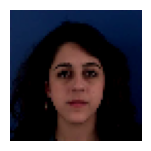

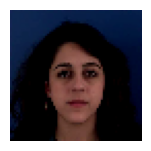

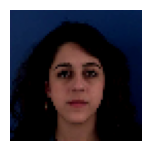

In [9]:
plot_normalized_sequence(previous_frame)
plot_normalized_sequence(current_frame)
plot_normalized_sequence(next_frame)

## Build the generator

Define the downsampler (encoder):

In [10]:
def downsample(filters, size, strides=2, apply_batchnorm=True):
  initializer = tf.random_normal_initializer(0., 0.02)

  result = tf.keras.Sequential()
  result.add(
      tf.keras.layers.Conv2D(filters, size, strides=strides, padding='same',
                             kernel_initializer=initializer, use_bias=False))

  if apply_batchnorm:
    result.add(tf.keras.layers.BatchNormalization())

  result.add(tf.keras.layers.LeakyReLU())

  return result

In [11]:
down_model = downsample(3, 4, 2)
down_result = down_model(current_frame, 0)
tf.print (down_result.shape)

2023-05-15 23:31:29.443144: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:424] Loaded cuDNN version 8600


TensorShape([1, 32, 32, 3])


Define the upsampler (decoder):

In [12]:
def upsample(filters, size, strides=2, apply_dropout=False):
  initializer = tf.random_normal_initializer(0., 0.02)

  result = tf.keras.Sequential()
  result.add(
    tf.keras.layers.Conv2DTranspose(filters, size, strides=strides,
                                    padding='same',
                                    kernel_initializer=initializer,
                                    use_bias=False))

  result.add(tf.keras.layers.BatchNormalization())

  if apply_dropout:
      result.add(tf.keras.layers.Dropout(0.5))

  result.add(tf.keras.layers.ReLU())

  return result

In [13]:
up_model = upsample(3, 4, 2)
up_result = up_model(down_result)
tf.print(up_result.shape)
tf.print(current_frame.shape)

TensorShape([1, 64, 64, 3])
(1, 64, 64, 3)


In [14]:
def Generator():
  inputs = tf.keras.layers.Input(shape=[IMG_WIDTH, IMG_HEIGHT, N_CHANNELS], dtype=tf.float64)

  down_stack = [
    downsample(128, 4, 2, apply_batchnorm=False),  # (batch_size, frames_group_size, 32, 32, 128)
    downsample(128, 4, 2),  # (batch_size, frames_group_size, 16, 16, 128)
    downsample(256, 4, 2),  # (batch_size, frames_group_size, 8, 8, 256)
    downsample(512, 4, 2),  # (batch_size, frames_group_size, 4, 4, 512)
    downsample(512, 4, 2),  # (batch_size, frames_group_size, 2, 2, 512)
  ]

  up_stack = [
    upsample(512, 4, 2, apply_dropout=False),  # (batch_size, frames_group_size, 4, 4, 512)
    # upsample(512, 4, 2, apply_dropout=True),  # (batch_size, frames_group_size, 4, 4, 512)
    upsample(256, 4, 2),  # (batch_size, frames_group_size, 8, 8, 256)
    upsample(128, 4, 2),  # (batch_size, frames_group_size, 16, 16, 256)
    upsample(128, 4, 2),  # (batch_size, frames_group_size, 32, 32, 128)
  ]

  initializer = tf.random_normal_initializer(0., 0.02)
  last = tf.keras.layers.Conv2DTranspose(N_CHANNELS, 4,
                                         strides=2,
                                         padding='same',
                                         kernel_initializer=initializer,
                                         activation='tanh')  # (batch_size, , frames_group_size, 64, 64, 3)

  x = inputs

  # Downsampling through the model
  skips = []
  for down in down_stack:
    x = down(x)
    skips.append(x)

  skips = reversed(skips[:-1])

  # Upsampling and establishing the skip connections
  for up, skip in zip(up_stack, skips):
    x = up(x)
    x = tf.keras.layers.Concatenate()([x, skip])

  x = last(x)

  return tf.keras.Model(inputs=inputs, outputs=x)

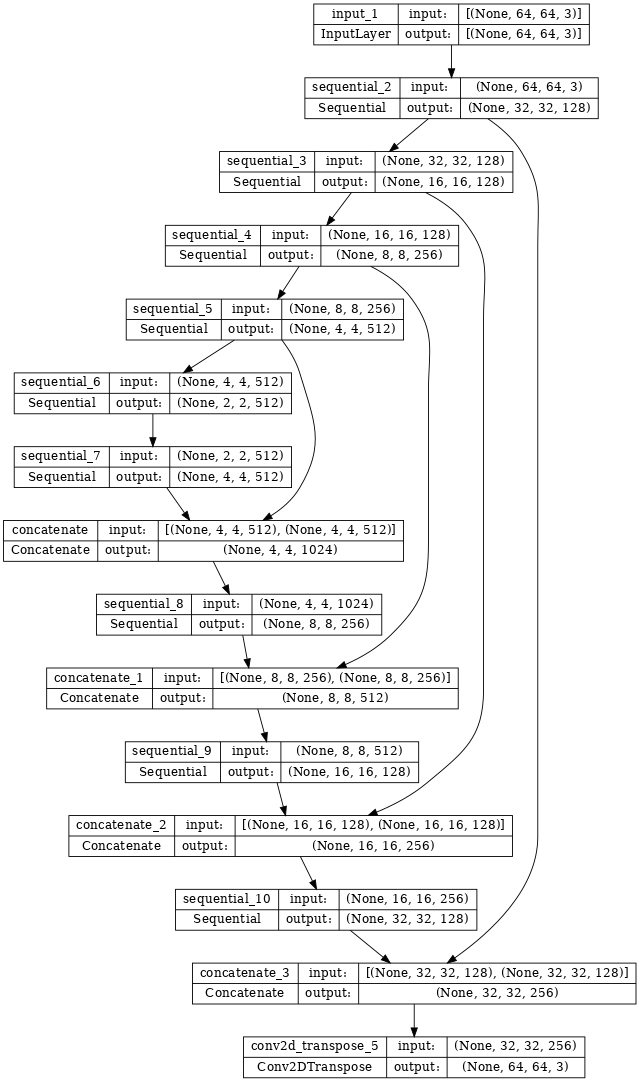

In [15]:
generator = Generator()
tf.keras.utils.plot_model(generator, show_shapes=True, dpi=64, to_file='output/generator.png')

Test the generator:

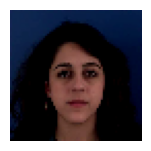

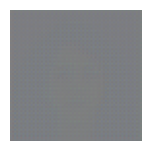

In [16]:
get_outputs =  generator(current_frame, training=False)

plot_normalized_sequence(current_frame)
plot_normalized_sequence(get_outputs)

## Get the landmarks

In [17]:
model = "../data/Mobilenet_v1.hdf5"
pr_model = load_model(model)

@tf.function
def preprocess_and_detect_landmarks_mobilenet(images):
    images =  normalized_sequence_to_images(images)
    images = tf.image.rgb_to_grayscale(images)
    landmarks = pr_model(images)
    return tf.reshape(landmarks, (-1, N_LANDMARKS, 2))

In [18]:
mp_holistic = mp.solutions.holistic
holistic_model = mp_holistic.Holistic(
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

landmark_points_68 = [162,234,93,58,172,136,149,148,152,377,378,365,397,288,323,454,389,71,63,105,66,107,336,
                  296,334,293,301,168,197,5,4,75,97,2,326,305,33,160,158,133,153,144,362,385,387,263,373,
                  380,61,39,37,0,267,269,291,405,314,17,84,181,78,82,13,312,308,317,14,87]

def default_landmarks(): # TODO: change to worst case landmarks
    landmars = np.array([
        [0.29012445, 0.46152872],
        [0.2892933 , 0.5601992 ],
        [0.2931674 , 0.60794365],
        [0.3160373 , 0.7112384 ],
        [0.33694965, 0.75203294],
        [0.3611762 , 0.7809247 ],
        [0.41771138, 0.82153064],
        [0.47449082, 0.84470284],
        [0.5121861 , 0.84691584],
        [0.54917306, 0.8418585 ],
        [0.600678  , 0.81461644],
        [0.64821094, 0.77014446],
        [0.6676827 , 0.74018675],
        [0.6844234 , 0.69848907],
        [0.7026569 , 0.5953291 ],
        [0.70517784, 0.54816395],
        [0.7053476 , 0.4507432 ],
        [0.31499407, 0.4301809 ],
        [0.3496217 , 0.41683587],
        [0.3800801 , 0.4043182 ],
        [0.41894913, 0.40356678],
        [0.46308845, 0.4068857 ],
        [0.55364776, 0.40440607],
        [0.59623   , 0.39843333],
        [0.63251084, 0.39682683],
        [0.6602349 , 0.40741068],
        [0.6877083 , 0.419833  ],
        [0.5091903 , 0.4663502 ],
        [0.51167095, 0.5154015 ],
        [0.5140266 , 0.55779254],
        [0.51499516, 0.5852076 ],
        [0.47420424, 0.62131006],
        [0.49072832, 0.6327596 ],
        [0.51303864, 0.63169634],
        [0.53469867, 0.6317114 ],
        [0.55023676, 0.61953837],
        [0.36748627, 0.49156916],
        [0.389509  , 0.47794613],
        [0.42158607, 0.47474214],
        [0.45398962, 0.49241695],
        [0.4244432 , 0.50182253],
        [0.3926721 , 0.5021153 ],
        [0.56044996, 0.48936403],
        [0.5910041 , 0.46954608],
        [0.6231319 , 0.47053385],
        [0.6443183 , 0.48294783],
        [0.62151766, 0.49532306],
        [0.58998615, 0.49713737],
        [0.43043962, 0.7109368 ],
        [0.46534333, 0.6881037 ],
        [0.48942912, 0.6805593 ],
        [0.51225406, 0.6830868 ],
        [0.5341855 , 0.6793185 ],
        [0.55653214, 0.6858657 ],
        [0.5862155 , 0.7075139 ],
        [0.5538744 , 0.7318629 ],
        [0.5344313 , 0.73881537],
        [0.5121652 , 0.74083835],
        [0.48921126, 0.7400408 ],
        [0.46820667, 0.734128  ],
        [0.44096255, 0.7079656 ],
        [0.4936156 , 0.7052665 ],
        [0.5114745 , 0.70541674],
        [0.52808297, 0.70446116],
        [0.5756917 , 0.7052983 ],
        [0.52984923, 0.708476  ],
        [0.51168627, 0.7092654 ],
        [0.49262676, 0.7093172 ]], dtype=np.float32)
    return landmars + tf.random.uniform(landmars.shape, -0.1, 0.1)

def preprocess_and_detect_landmarks_mediapipe_numpy(images):
    images =  normalized_sequence_to_images(images)
    images = np.array(images, dtype=np.uint8)
    all_landmarks = []
    for image in images:
        landmarks = []
        results = holistic_model.process(image)
        if results.face_landmarks is None:
            landmarks = default_landmarks()
        else:
            for landmark in results.face_landmarks.landmark:
                landmarks.append([landmark.x, landmark.y])
            landmarks = np.array(landmarks, dtype=np.float32)
            landmarks = landmarks[landmark_points_68]
        all_landmarks.append(landmarks)
    return np.array(all_landmarks, dtype=np.float32)

def preprocess_and_detect_landmarks_mediapipe(images):
    [results,] = tf.numpy_function(preprocess_and_detect_landmarks_mediapipe_numpy, [images], Tout=[tf.float32])
    results = tf.convert_to_tensor(results, dtype=tf.float32)
    results.set_shape((N_LANDMARKS, 2)) # TODO: fix to consider batch size
    results = tf.expand_dims(results, axis=0)
    return results    

In [19]:
def landmarks_to_array_dlib(landmarks):
    x = []
    y = []
    for current_landmarks in landmarks:
        x.append(current_landmarks.x)
        y.append(current_landmarks.y)
    return np.array([x, y])

def preprocess_and_detect_landmarks_dlib_numpy(clip): # TODO: normalize landmarks by the distance between the eyes
    clip_landmarks = []
    for frame in clip:
        frame =  normalized_sequence_to_images(frame)
        frame = np.array(frame, dtype=np.uint8)
        # Only considering the first face
        faces = face_recognition.api._raw_face_landmarks(face_image=frame)
        if len(faces) > 0:
            landmarks_array = landmarks_to_array_dlib(faces[0].parts())
            clip_landmarks.append(landmarks_array) # TODO: fix to work with batch size > 1
    if len(clip_landmarks) > 0:
        clip_landmarks = np.array(clip_landmarks)
        clip_landmarks = np.moveaxis(clip_landmarks, 1, 2)
    else:
        clip_landmarks = default_landmarks()
        clip_landmarks = np.expand_dims(clip_landmarks, axis=0)
    return np.ndarray.astype(clip_landmarks, dtype=np.float32)

def preprocess_and_detect_landmarks_dlib(images):
    [results,] = tf.numpy_function(preprocess_and_detect_landmarks_dlib_numpy, [images], Tout=[tf.float32])
    results = tf.convert_to_tensor(results, dtype=tf.float32)
    results.set_shape((N_LANDMARKS, 2)) # TODO: fix to consider batch size
    results = tf.expand_dims(results, axis=0)
    return results    

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [20]:
preprocess_and_detect_landmarks = preprocess_and_detect_landmarks_dlib

In [21]:

def compute_displacements_interpolation(points_a, points_b, image_height=IMG_HEIGHT, image_width=IMG_WIDTH, fill_value=0):
    """
    Computes the interpolation for all points of the displacements by the distance between the vertices of points_a and Points_b.
    Assumes that the input vertices and displacements are arrays of shape (num_triangles, 3, 2),
    where num_triangles is the number of triangles and each triangle is defined by three (x, y) vertex coordinates.
    Assumes that the input x and y are arrays of shape (height, width), representing the 2D grid of points to compute the displacements for.
    Returns an array of shape (height, width, 2), representing the displacements of each point on the grid.
    """
    points_a = np.asarray(points_a)
    points_b = np.asarray(points_b)
    points_a = np.reshape(points_a, (-1, 2)) # TODO: fix to work with batch size > 1
    points_b = np.reshape(points_b, (-1, 2)) # TODO: fix to work with batch size > 1

    displacements_values = np.linalg.norm(points_b - points_a, axis=1)
    interpolator_a = LinearNDInterpolator(points_a, displacements_values, fill_value=fill_value)
    interpolator_b = LinearNDInterpolator(points_b, displacements_values, fill_value=fill_value)
    X = np.arange(0, image_height)
    Y = np.arange(0, image_width)
    X, Y = np.meshgrid(X, Y)
    displacements_map_a = interpolator_a(X, Y)
    displacements_map_b = interpolator_b(X, Y)
    displacements_map = np.mean([displacements_map_a, displacements_map_b], axis=0)
    return np.ndarray.astype(displacements_map, np.float32)

@tf.function
def get_tensors_displacements(points_a, points_b, image_height=IMG_HEIGHT, image_width=IMG_WIDTH):
    [results,] = tf.numpy_function(compute_displacements_interpolation, [points_a, points_b, image_height, image_width], Tout=[tf.float32])
    results = tf.convert_to_tensor(results, dtype=tf.float32)
    results.set_shape((IMG_HEIGHT, IMG_WIDTH))
    # add batch and channel dimensions
    # results = tf.expand_dims(results, axis=0)
    # results = tf.expand_dims(results, axis=-1)
    return results

In [22]:
current_frames_landmarks = preprocess_and_detect_landmarks(current_frame)
previous_frame_landmarks = preprocess_and_detect_landmarks(previous_frame)
gen_output_landmarks = preprocess_and_detect_landmarks(get_outputs)
tf.print(current_frame.shape)
tf.print(current_frames_landmarks.shape) # (batch, landmarks, (x,y,z))
tf.print(current_frames_landmarks[0,0])

(1, 64, 64, 3)
TensorShape([1, 68, 2])
[0.292533696 0.461376697]


In [23]:
displacement_maps = get_tensors_displacements(previous_frame_landmarks[0], current_frames_landmarks[0])
tf.print(displacement_maps.shape)
a = get_tensors_displacements(previous_frame_landmarks[0], gen_output_landmarks[0])
tf.print(a.shape)

TensorShape([64, 64])
TensorShape([64, 64])


### Define the generator loss

In [24]:
loss_object = tf.keras.losses.BinaryCrossentropy(from_logits=True)

In [25]:
@tf.function
def euclidean_distance(a, b):
  return tf.math.sqrt(tf.math.reduce_sum(tf.math.pow(a-b, 2), axis=-1))

@tf.function
def all_pairs_distances(x):
  x = tf.reshape(x, (-1, x.shape[-1]))
  indices = tf.stack(list(combinations(range(len(x)), 2)))
  a_index = indices[:,0]
  b_index = indices[:,1]
  a = tf.gather(x, a_index)
  b = tf.gather(x, b_index)
  return euclidean_distance(a,b)

@tf.function
def l1_loss(previous, current):
  return  tf.math.abs(current-previous)

@tf.function
def pairwise_loss(y_true, y_pred):
  y_true = all_pairs_distances(y_true)
  y_pred = all_pairs_distances(y_pred)
  return tf.math.reduce_mean(euclidean_distance(y_true, y_pred))

@tf.function
def get_luminance(image):
  output = normalized_sequence_to_images(image)
  output = tfio.experimental.color.rgb_to_ycbcr(output)
  output = output[...,0] # get y from ycbcr
  return tf.cast(output, tf.float32)

@tf.function
def apply_luminance_loss(previous, current, loss_function):
  previous_luminance = get_luminance(previous)
  current_luminance = get_luminance(current)
  return loss_function(previous_luminance, current_luminance)

@tf.function
def mean_loss(y_true, y_pred, loss_function):
  y_true = tf.cast(y_true, tf.float32)
  y_pred = tf.cast(y_pred, tf.float32)
  return tf.math.reduce_mean(loss_function(y_true, y_pred))

@tf.function
def coherence_mean_loss(previous_y_true, y_true, previous_y_pred, y_pred, loss_function):
  loss_true = apply_luminance_loss(previous_y_true, y_true, loss_function)
  loss_pred = apply_luminance_loss(previous_y_pred, y_pred, loss_function)
  return tf.math.reduce_mean(tf.abs(loss_true - loss_pred))

@tf.function
def coherence_mean_landmarks_loss(previous_y_true_landmarks, y_true_landmarks, previous_y_pred_landmarks, y_pred_landmarks, loss_function):
  previous_y_true_landmarks = tf.cast(previous_y_true_landmarks, tf.float32)
  y_true_landmarks = tf.cast(y_true_landmarks, tf.float32)
  previous_y_pred_landmarks = tf.cast(previous_y_pred_landmarks, tf.float32)
  y_pred_landmarks = tf.cast(y_pred_landmarks, tf.float32)
  loss_true = loss_function(previous_y_true_landmarks, y_true_landmarks)
  loss_pred = loss_function(previous_y_pred_landmarks, y_pred_landmarks)
  return tf.math.reduce_mean(tf.abs(loss_true - loss_pred))

## Comparing loss functions

In [26]:
GENERATOR_LOSS_FUNCTIONS = {
    'l1': l1_loss,
    'l2': euclidean_distance,
    'pairwise': pairwise_loss,
    'displacements': get_tensors_displacements,
    # 'perceptual': perceptual_loss,
    # 'test_landmarks': landmark_loss
}

landmarks_losses_functions = ['pairwise', 'displacements']

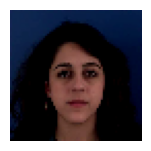

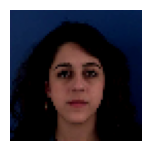

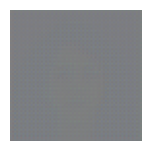

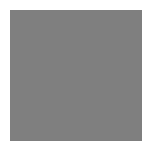

current_frame dtype('float64')
next_frame dtype('float64')
gen_output_sample tf.float32
gen_output_next_sample tf.float32


In [27]:
gen_output_sample = generator(current_frame, training=False)
gen_output_next_sample = generator(gen_output_sample, training=False)
plot_normalized_sequence(current_frame)
plot_normalized_sequence(next_frame)
plot_normalized_sequence(gen_output_sample)
plot_normalized_sequence(gen_output_next_sample)

# print types
tf.print("current_frame", current_frame.dtype)
tf.print("next_frame", next_frame.dtype)
tf.print("gen_output_sample", gen_output_sample.dtype)
tf.print("gen_output_next_sample", gen_output_next_sample.dtype)

In [28]:
for loss_function in GENERATOR_LOSS_FUNCTIONS:
    if loss_function not in landmarks_losses_functions:
        tf.print("================================", loss_function, "================================")
        loss_value = mean_loss(next_frame,gen_output_sample,GENERATOR_LOSS_FUNCTIONS[loss_function])
        tf.print(loss_value)

================================ l1 ================================
0.770178497
================================ l2 ================================
1.36047029


In [29]:
for loss_function in GENERATOR_LOSS_FUNCTIONS:
    if loss_function not in landmarks_losses_functions:
        print(current_frame.shape)
        tf.print("================================", loss_function, "================================")
        loss_value = coherence_mean_loss(current_frame, next_frame, gen_output_sample, gen_output_next_sample, GENERATOR_LOSS_FUNCTIONS[loss_function])
        tf.print(loss_value)

(1, 64, 64, 3)
================================ l1 ================================
1.64990234
(1, 64, 64, 3)
================================ l2 ================================
11.3494368


2023-05-15 23:31:36.272446: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:637] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


In [30]:
for loss_function in GENERATOR_LOSS_FUNCTIONS:
    tf.print("================================", loss_function, "================================")
    current_frame_landmarks = preprocess_and_detect_landmarks(current_frame)
    next_frame_landmarks = preprocess_and_detect_landmarks(next_frame)
    gen_output_sample_landmarks = preprocess_and_detect_landmarks(gen_output_sample)
    gen_output_next_sample_landmarks = preprocess_and_detect_landmarks(gen_output_next_sample)
    loss_value = mean_loss(current_frame_landmarks[0], gen_output_sample_landmarks[0], GENERATOR_LOSS_FUNCTIONS[loss_function])
    tf.print(loss_value)

================================ l1 ================================
0.00188509398
================================ l2 ================================
0.0028471183
================================ pairwise ================================
0.119711176
================================ displacements ================================
0


In [31]:
for loss_function in GENERATOR_LOSS_FUNCTIONS:
    tf.print("================================", loss_function, "================================")
    current_frame_landmarks = preprocess_and_detect_landmarks(current_frame)
    next_frame_landmarks = preprocess_and_detect_landmarks(next_frame)
    gen_output_sample_landmarks = preprocess_and_detect_landmarks(gen_output_sample)
    gen_output_next_sample_landmarks = preprocess_and_detect_landmarks(gen_output_next_sample)
    loss_value = coherence_mean_landmarks_loss(current_frame_landmarks[0], next_frame_landmarks[0], gen_output_sample_landmarks[0], gen_output_next_sample_landmarks[0], GENERATOR_LOSS_FUNCTIONS[loss_function])
    tf.print(loss_value)

================================ l1 ================================
0.00213422766
================================ l2 ================================
0.00328622502
================================ pairwise ================================
0.117370181
================================ displacements ================================
0


In [32]:
def generator_loss(disc_generated_output, previous_gen, current_gen, previous_target, current_target):
  gan_loss = loss_object(tf.ones_like(disc_generated_output), disc_generated_output)

  if MAIN_LOSS:
    main_loss = mean_loss(current_target, current_gen, GENERATOR_LOSS_FUNCTIONS[MAIN_LOSS]) * LAMBDA1
  else:
    main_loss = 0

  if COHERENCE_LOSS:
    coherence_loss = coherence_mean_loss(previous_target, current_target, previous_gen, current_gen, GENERATOR_LOSS_FUNCTIONS[COHERENCE_LOSS]) * LAMBDA2
  else:
    coherence_loss = 0

  if LANDMARKS_LOSS or LANDMARKS_COHERENCE_LOSS:
    current_target_landmarks = preprocess_and_detect_landmarks(current_target)[0] # TODO: fix to work with batch > 1
    current_gen_landmarks = preprocess_and_detect_landmarks(current_gen)[0] # TODO: fix to work with batch > 1
    tf.print("current_target_landmarks", current_target_landmarks.shape)
    tf.print("current_gen_landmarks", current_gen_landmarks.shape)
  
  if LANDMARKS_COHERENCE_LOSS:
    previous_target_landmarks = preprocess_and_detect_landmarks(previous_target)[0] # TODO: fix to work with batch > 1
    previous_gen_landmarks = preprocess_and_detect_landmarks(previous_gen)[0] # TODO: fix to work with batch > 1
    tf.print("previous_target_landmarks", previous_target_landmarks.shape)
    tf.print("previous_gen_landmarks", previous_gen_landmarks.shape)

  # TODO: compute landmarks only once per image
  if LANDMARKS_LOSS:
    # landmarks_loss = mean_loss(current_target_landmarks, current_gen_landmarks, GENERATOR_LOSS_FUNCTIONS[LANDMARKS_LOSS]) * LAMBDA3
    landmarks_loss = mean_loss(current_target_landmarks, current_gen_landmarks, GENERATOR_LOSS_FUNCTIONS[LANDMARKS_LOSS]) * LAMBDA3
  else:
    landmarks_loss = 0
  
  if LANDMARKS_COHERENCE_LOSS:
    # landmarks_coherence_loss = coherence_mean_landmarks_loss(previous_target_landmarks, current_target_landmarks, previous_gen_landmarks, current_gen_landmarks, GENERATOR_LOSS_FUNCTIONS[LANDMARKS_COHERENCE_LOSS]) * LAMBDA4
    landmarks_coherence_loss = coherence_mean_landmarks_loss(previous_target_landmarks, current_target_landmarks, previous_gen_landmarks, current_gen_landmarks, GENERATOR_LOSS_FUNCTIONS[LANDMARKS_COHERENCE_LOSS]) * LAMBDA4
  else:
    landmarks_coherence_loss = 0

  total_gen_loss = gan_loss + main_loss + coherence_loss + landmarks_loss

  return total_gen_loss, gan_loss, main_loss, coherence_loss, landmarks_loss, landmarks_coherence_loss

Comparing new loss function

## Build the discriminator

Let's define the discriminator:

In [33]:
def Discriminator():
  initializer = tf.random_normal_initializer(0., 0.02)

  inp = tf.keras.layers.Input(shape=[IMG_WIDTH, IMG_HEIGHT, N_CHANNELS], name='current_frame')
  tar = tf.keras.layers.Input(shape=[IMG_WIDTH, IMG_HEIGHT, N_CHANNELS], name='folowing_frame')

  x = tf.keras.layers.concatenate([inp, tar])  # (batch_size, 256, 256, channels*2)

  down1 = downsample(64, 4, 2, apply_batchnorm=False)(x)  # (batch_size, 128, 128, 64)
  down2 = downsample(128, 4, 2)(down1)  # (batch_size, 64, 64, 128)
  # down3 = downsample(256, 4)(down2)  # (batch_size, 32, 32, 256)

  zero_pad1 = tf.keras.layers.ZeroPadding2D()(down2)  # (batch_size, 34, 34, 256)
  conv = tf.keras.layers.Conv2D(256, 4, strides=1,
                                kernel_initializer=initializer,
                                use_bias=False)(zero_pad1)  # (batch_size, 31, 31, 512)

  batchnorm1 = tf.keras.layers.BatchNormalization()(conv)

  leaky_relu = tf.keras.layers.LeakyReLU()(batchnorm1)

  zero_pad2 = tf.keras.layers.ZeroPadding2D()(leaky_relu)  # (batch_size, 33, 33, 512)

  last = tf.keras.layers.Conv2D(1, 2, strides=1,
                                kernel_initializer=initializer)(zero_pad2)  # (batch_size, 30, 30, 1)

  return tf.keras.Model(inputs=[inp, tar], outputs=last)

Visualize the discriminator model architecture:

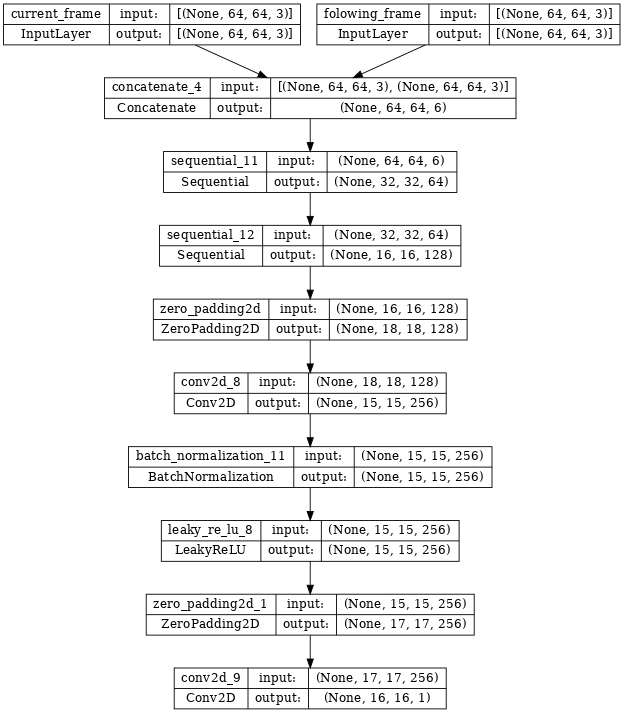

In [34]:
discriminator = Discriminator()
tf.keras.utils.plot_model(discriminator, show_shapes=True, dpi=64, to_file='output/discriminator.png')

Test the discriminator:

TensorShape([1, 16, 16, 1])


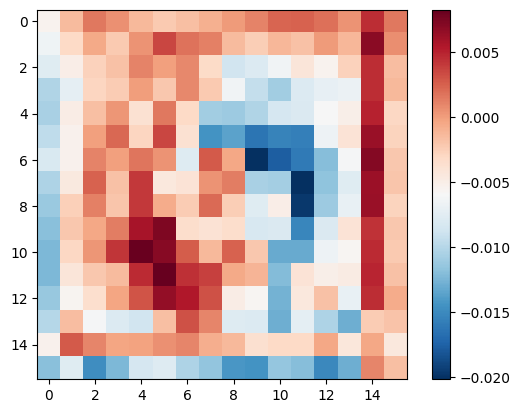

In [35]:
disc_out = discriminator([current_frame, gen_output_sample], training=False)
tf.print(disc_out.shape)
plt.imshow(disc_out[0, ..., -1], cmap='RdBu_r')
plt.colorbar()
plt.show()
plt.close()

### Define the discriminator loss

In [36]:
def discriminator_loss(disc_real_output, disc_generated_output):
  real_loss = loss_object(tf.ones_like(disc_real_output), disc_real_output)

  generated_loss = loss_object(tf.zeros_like(disc_generated_output), disc_generated_output)

  total_disc_loss = real_loss + generated_loss

  return total_disc_loss

In [37]:
gen_total_loss, gen_gan_loss, gen_target_predicted, gen_coherence_loss, gen_landmarks_loss, gen_landmarks_coherence_loss = generator_loss(
    disc_out, gen_output_sample, gen_output_next_sample, current_frame, next_frame
)
print(gen_total_loss)

current_target_landmarks TensorShape([68, 2])
current_gen_landmarks TensorShape([68, 2])
previous_target_landmarks TensorShape([68, 2])
previous_gen_landmarks TensorShape([68, 2])
tf.Tensor(776.45355, shape=(), dtype=float32)


## Define the optimizers and a checkpoint-saver


In [38]:
generator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

In [39]:
BASE_DIR = APP_PATH / 'output'
checkpoint_dir = str(BASE_DIR /  f'{MAIN_LOSS}_{LAMBDA1}_{COHERENCE_LOSS}_{LAMBDA2}' / 'training_checkpoints')
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                 discriminator_optimizer=discriminator_optimizer,
                                 generator=generator,
                                 discriminator=discriminator)

## Generate images

Note: The `training=True` is intentional here since you want the batch statistics, while running the model on the test dataset. If you use `training=False`, you get the accumulated statistics learned from the training dataset (which you don't want).

In [40]:
def plot_results(sample_target, sample_input, gen_output):

  display_list = [sample_input, sample_target, gen_output]
  title = ['Input Sequence', 'Ground Truth', 'Predicted Sequence']

  for i in range(3):
    tf.print(title[i])
    display_list[i] = display_list[i]
    plot_normalized_sequence(display_list[i])

def generate_sequences(model, sample_target, sample_input):
  prediction = model(sample_input, training=True)
  plot_results(sample_input, sample_target, prediction)

Test the function:

Input Sequence


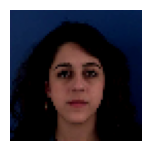

Ground Truth


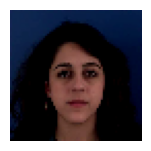

Predicted Sequence


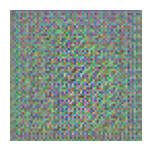

In [41]:
generate_sequences(generator, next_frame, current_frame)

## Training


In [42]:
log_dir=BASE_DIR / "logs/"
log_file = log_dir / "fit" / datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

summary_writer = tf.summary.create_file_writer(str(log_file))

In [43]:
@tf.function
def train_step(previous_frame, current_frame, next_frame, step):
  with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
    previous_gen_output = generator(previous_frame, training=True)
    current_gen_output = generator(current_frame, training=True)
    

    disc_real_output = discriminator([current_frame, next_frame], training=True)
    disc_generated_output = discriminator([current_frame, current_gen_output], training=True)
    
    gen_total_loss, gen_gan_loss, gen_target_predicted, gen_coherence_loss, gen_landmarks_loss, gen_landmarks_coherence_loss = generator_loss(
      disc_generated_output, previous_gen_output, current_gen_output, current_frame, next_frame
    )
    disc_loss = discriminator_loss(disc_real_output, disc_generated_output)
    generator_gradients = gen_tape.gradient(gen_total_loss,
                                            generator.trainable_variables)
    discriminator_gradients = disc_tape.gradient(disc_loss,
                                                discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(generator_gradients,
                                            generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(discriminator_gradients,
                                                discriminator.trainable_variables))
    with summary_writer.as_default():
      summary_step = step//1000
      tf.summary.scalar(f'gen_total_loss', gen_total_loss, step=summary_step)
      tf.summary.scalar(f'gen_gan_loss', gen_gan_loss, step=summary_step)
      tf.summary.scalar(f'disc_loss', disc_loss, step=summary_step)
      if MAIN_LOSS:
        tf.summary.scalar(f'gen_target_predicted_{MAIN_LOSS}', gen_target_predicted, step=summary_step)
      if COHERENCE_LOSS:
        tf.summary.scalar(f'gen_coherence_{COHERENCE_LOSS}', gen_coherence_loss, step=summary_step)
      if LANDMARKS_LOSS:
        tf.summary.scalar(f'gen_landmarks_loss_{LANDMARKS_LOSS}', gen_landmarks_loss, step=summary_step)
      if LANDMARKS_COHERENCE_LOSS:
        tf.summary.scalar(f'gen_landmarks_coherence_loss_{LANDMARKS_COHERENCE_LOSS}', gen_landmarks_coherence_loss, step=summary_step)

In [44]:
def fit(train_dataset_generator, previous_frame_ex, current_frame_ex, next_frame_ex, steps):

  train_dataset = train_dataset_generator.take(steps)
  pbar = tqdm(range(steps), total=steps)
  for step in pbar:
    with tf.profiler.experimental.Trace('train', step_num=step, _r=1):
      previous_frame, current_frame, next_frame = next(train_dataset)

      if (step) % 1000 == 0:
        clear_output(wait=True)
        display(pbar.container)
        generate_sequences(generator, current_frame_ex, next_frame_ex)
        tf.print("Working on input:")
        plot_normalized_sequence(current_frame)
        tf.print("Working on target:")
        plot_normalized_sequence(next_frame)

      train_step(previous_frame, current_frame, next_frame, step)

      # Save (checkpoint) the model every 5k steps
      if (step + 1) % 5000 == 0:
          checkpoint.save(file_prefix=checkpoint_prefix)

In [45]:
previous_frame_ex, current_frame_ex, next_frame_ex = next(test_generator)

Restart datatset generator from begining

In [46]:
train_generator = FrameDataGenerator(train_paths, batch_size=BATCH_SIZE)

In [47]:
tf.profiler.experimental.start(str(log_dir))

2023-05-15 23:31:42.679832: I tensorflow/tsl/profiler/lib/profiler_session.cc:104] Profiler session initializing.
2023-05-15 23:31:42.679902: I tensorflow/tsl/profiler/lib/profiler_session.cc:119] Profiler session started.
2023-05-15 23:31:42.680027: I tensorflow/compiler/xla/backends/profiler/gpu/cupti_tracer.cc:1679] Profiler found 1 GPUs


  0%|          | 0/100000 [00:00<?, ?it/s]

Input Sequence


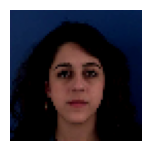

Ground Truth


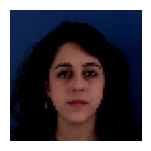

Predicted Sequence


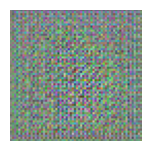

Working on input:


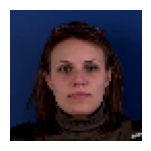

Working on target:


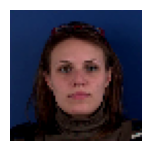

current_target_landmarks TensorShape([68, 2])
current_gen_landmarks TensorShape([68, 2])
previous_target_landmarks TensorShape([68, 2])
previous_gen_landmarks TensorShape([68, 2])


2023-05-15 23:31:48.570318: I tensorflow/compiler/xla/service/service.cc:169] XLA service 0x7f84d06a5630 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2023-05-15 23:31:48.570398: I tensorflow/compiler/xla/service/service.cc:177]   StreamExecutor device (0): NVIDIA RTX A4000, Compute Capability 8.6
2023-05-15 23:31:48.578853: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2023-05-15 23:31:48.761981: I ./tensorflow/compiler/jit/device_compiler.h:180] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


current_target_landmarks TensorShape([68, 2])
current_gen_landmarks TensorShape([68, 2])
previous_target_landmarks TensorShape([68, 2])
previous_gen_landmarks TensorShape([68, 2])
current_target_landmarks TensorShape([68, 2])
current_gen_landmarks TensorShape([68, 2])
previous_target_landmarks TensorShape([68, 2])
previous_gen_landmarks TensorShape([68, 2])
current_target_landmarks TensorShape([68, 2])
current_gen_landmarks TensorShape([68, 2])
previous_target_landmarks TensorShape([68, 2])
previous_gen_landmarks TensorShape([68, 2])
current_target_landmarks TensorShape([68, 2])
current_gen_landmarks TensorShape([68, 2])
previous_target_landmarks TensorShape([68, 2])
previous_gen_landmarks TensorShape([68, 2])
current_target_landmarks TensorShape([68, 2])
current_gen_landmarks TensorShape([68, 2])
previous_target_landmarks TensorShape([68, 2])
previous_gen_landmarks TensorShape([68, 2])
current_target_landmarks TensorShape([68, 2])
current_gen_landmarks TensorShape([68, 2])
previous_ta

KeyboardInterrupt: 

In [48]:
fit(train_generator, previous_frame_ex, current_frame_ex, next_frame_ex, steps=STEPS)

## Restore the latest checkpoint and test the network

In [ ]:
!ls {checkpoint_dir}

In [ ]:
# Restoring the latest checkpoint in checkpoint_dir
checkpoint.restore(tf.train.latest_checkpoint(checkpoint_dir))

## Generate some images using the test set

In [ ]:
test_generator = FrameDataGenerator(test_paths, batch_size=BATCH_SIZE)

for i in range(0,10):
  previous_frame, current_frame, next_frame = next(test_generator)
  predicted_output = generator(current_frame, training=False)
  plot_results(current_frame, next_frame, predicted_output)

In [ ]:
# evaluating the results with SSIM
def evaluate_metrics(target_sequence, generated_output):
    #cast to float32
    target_sequence = tf.cast(target_sequence, tf.float32)
    generated_output = tf.cast(generated_output, tf.float32)
    #compute ssim
    ssim_score = tf.image.ssim(generated_output, target_sequence, max_val=1)
    #compute psnr
    psnr_score = tf.image.psnr(generated_output, target_sequence, max_val=1)
    #compute mse
    mse_score = tf.keras.losses.MSE(generated_output, target_sequence)
    #compute l1
    l1_score = tf.keras.losses.MAE(generated_output, target_sequence)
    return ssim_score, psnr_score, mse_score, l1_score


ssim_scores = []
psnr_scores = []
mse_scores = []
l1_scores = []

test_generator = FrameDataGenerator(test_paths)
test_frames = np.array(list(test_generator))

batch = 1000
for i in tqdm(range(0, len(test_frames), batch)):
  input_frames = test_frames[i:i+batch,1,:,:,:]
  target_frames = test_frames[i:i+batch,2,0,:,:]
  predicted_frames = np.array([generator(f, training=False) for f in input_frames])[:,0,...]
  ssim_score, psnr_score, mse_score, l1_score = evaluate_metrics(target_frames, predicted_frames)
  ssim_scores.extend(ssim_score)
  psnr_scores.extend(psnr_score)
  mse_scores.extend(mse_score)
  l1_scores.extend(l1_score)

In [ ]:
scores = {
    "SSIM": ssim_scores,
    "PSNR": psnr_scores,
    "MSE": mse_scores,
    "L1": l1_scores,
}

score_string = ""
for score_name in scores.keys():
    mean = tf.math.reduce_mean(scores[score_name])
    tf.print(f"{score_name} score: {mean}")
    score_string += f"{mean}\t"

tf.print(score_string)

In [ ]:
train_generator = FrameDataGenerator(train_paths)
train_frames = np.array(list(train_generator))
tf.print(train_frames.shape)

In [ ]:
test_generator = FrameDataGenerator(test_paths)
test_frames = np.array(list(test_generator))
tf.print(test_frames.shape)

## Different order

In [ ]:
new_order = [0, 10, 1, 11, 2, 12, 3, 13, 4, 14, 5, 15, 6, 16, 7, 17, 8, 18, 9]

# # Run the trained model on a few examples from the test set
# for i, (inp, tar) in enumerate(test_dataset.take(5)):
#   inp = tf.gather(inp, new_order, axis=-1)
#   tar = tf.gather(tar, new_order, axis=-1)
#   # inp = inp[..., new_order]
#   # tar = tar[..., new_order]
#   tf.print(i)
#   generate_sequences(generator, inp, tar, save_dir=save_dir)